# 2.4 PyTorch Dataset / DataLoader 실습

**목표**
1. `Dataset` 의 3대 메서드(`__init__`, `__len__`, `__getitem__`) 가 실제로 어떻게 동작하는지 확인
2. `DataLoader` 가 내부에서 배치·셔플·collate 를 어떻게 수행하는지 코드로 분해
3. 2.1~2.3 의 모든 교훈(sliding window + IS-only scaler) 을 하나의 `SequenceDataset` 클래스로 통합
4. 자주 하는 실수(Dataset 내부 `fit`) 의 결과를 숫자로 확인

**구성**
- Step 1. 환경설정 & 데이터 로드 (torch 있으면 실제 PyTorch, 없으면 mini 구현)
- Step 2. Toy Dataset — 최소 구현으로 규약 이해
- Step 3. DataLoader — 배치(B, T, F) 만들기
- Step 4. SequenceDataset — scaler 주입 패턴
- Step 5. IS / OOS DataLoader 구성
- Step 6. Pre-computed vs On-the-fly — `__getitem__` 속도 비교
- Step 7. 안티패턴 — Dataset 내부 `fit` 은 왜 위험한가
- Step 8. 자가 점검 질문 해설 + 체크리스트

이 노트북의 모든 숫자는 `04_pytorch_dataset.md` 의 주장과 1:1 로 대응됩니다.

## Step 1. 환경설정 & 데이터 로드

**torch 유무를 자동 감지**합니다.
- 설치되어 있으면 실제 `torch.utils.data.Dataset / DataLoader` 사용
- 없으면 동일 인터페이스의 **mini 구현** 사용 (sandbox 검증용)

두 경로 모두 이후 코드는 수정 없이 동작합니다. 이 `try/except` 패턴은 배포용 스크립트에서도 유용합니다.

In [1]:
# ── 한글 폰트 (CLAUDE.md 규칙)
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows':   plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  plt.rcParams['font.family'] = 'AppleGothic'
else:
    import koreanize_matplotlib
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 분석 라이브러리
import numpy as np
import pandas as pd
import time
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler

# ── Dataset / DataLoader 확보 (torch 있으면 실제, 없으면 mini 구현)
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    HAS_TORCH = True
    print(f'torch {torch.__version__} — 실제 PyTorch 사용')
    def to_tensor(x): return torch.from_numpy(np.ascontiguousarray(x))
except ImportError:
    HAS_TORCH = False
    print('torch 없음 — 교육용 mini 구현 사용 (인터페이스는 PyTorch 와 동일)')

    class Dataset:
        def __len__(self): raise NotImplementedError
        def __getitem__(self, idx): raise NotImplementedError

    class DataLoader:
        def __init__(self, dataset, batch_size=1, shuffle=False, drop_last=False):
            self.dataset = dataset
            self.batch_size = batch_size
            self.shuffle = shuffle
            self.drop_last = drop_last
        def __iter__(self):
            n = len(self.dataset)
            idx = np.arange(n)
            if self.shuffle: np.random.shuffle(idx)
            for i in range(0, n, self.batch_size):
                batch_idx = idx[i:i + self.batch_size]
                if self.drop_last and len(batch_idx) < self.batch_size: break
                xs, ys = [], []
                for j in batch_idx:
                    x, y = self.dataset[j]
                    xs.append(x); ys.append(y)
                yield np.stack(xs), np.stack(ys)
        def __len__(self):
            n = len(self.dataset)
            return n // self.batch_size if self.drop_last else (n + self.batch_size - 1) // self.batch_size

    def to_tensor(x): return np.ascontiguousarray(x)

torch 2.11.0+cu126 — 실제 PyTorch 사용


In [2]:
# ── 데이터 로드
CSV = '../../black_litterman/data/panels/MSFT.csv'
FEATURE_COLS = [
    'log_return_1d','simple_return_1d',
    'mom_1m','mom_3m','mom_6m','mom_12m','mom_12m_skip_1m',
    'vol_20d_ann','vol_60d_ann','vol_252d_ann',
    'mkt_rf','smb','hml','rmw','cma','rf','mom_factor',
]
TARGET_COL = 'fwd_ret_21d'
h, T = 21, 60

df = pd.read_csv(CSV, index_col='date', parse_dates=True)
df = df[(df.index >= '2020-12-01') & (df.index <= '2025-12-31')].copy()
df[TARGET_COL] = df['adj_close'].shift(-h) / df['adj_close'] - 1
df = df.dropna(subset=FEATURE_COLS).copy()
N = len(df)
print(f'N = {N}일, F = {len(FEATURE_COLS)} 피처, T = {T}, h = {h}')

N = 1276일, F = 17 피처, T = 60, h = 21


## Step 2. Toy Dataset — `__len__` / `__getitem__` 최소 구현

가장 작은 Dataset 을 만들어 **규약** 을 체감합니다. sliding window 만 적용하고, scaler / NaN 처리는 다음 단계로 미룹니다.

```python
class ToyWindowDataset(Dataset):
    def __len__(self):             # 이 Dataset 이 가진 샘플 수
    def __getitem__(self, idx):    # idx 번째 샘플 (X, y) 반환
```

In [3]:
class ToyWindowDataset(Dataset):
    """lookback 만 적용한 최소 Dataset."""
    def __init__(self, df, feature_cols, target_col, T):
        self.X_raw = df[feature_cols].to_numpy(dtype=np.float32)
        self.y_raw = df[target_col].to_numpy(dtype=np.float32)
        self.T = T

    def __len__(self):
        return len(self.y_raw) - self.T + 1

    def __getitem__(self, idx):
        x = self.X_raw[idx : idx + self.T]      # (T, F)
        y = self.y_raw[idx + self.T - 1]        # scalar
        return to_tensor(x), to_tensor(np.array([y], dtype=np.float32))

toy = ToyWindowDataset(df, FEATURE_COLS, TARGET_COL, T=T)
print(f'len(toy) = {len(toy)}  (= N - T + 1 = {N} - {T} + 1 = {N - T + 1})')

x0, y0 = toy[0]
print(f'toy[0]: x shape = {tuple(x0.shape)},  y shape = {tuple(y0.shape)}')
print(f'        x[:3, :3] =')
print(np.asarray(x0)[:3, :3])

len(toy) = 1217  (= N - T + 1 = 1276 - 60 + 1 = 1217)
toy[0]: x shape = (60, 17),  y shape = (1,)
        x[:3, :3] =
[[ 0.00994708  0.00999672  0.0706578 ]
 [-0.00389278 -0.00388521  0.06723586]
 [-0.00526063 -0.00524682  0.04055065]]


## Step 3. DataLoader — 배치 (B, T, F) 만들기

`DataLoader` 가 하는 일을 한 줄씩 짚어보면:
1. `range(len(dataset))` 을 셔플(옵션) 해서 인덱스 리스트 생성
2. `batch_size` 만큼씩 잘라 각 인덱스에서 `dataset[i]` 호출
3. 결과를 **stack** 해서 `(B, T, F)` 배치 텐서로 묶음 (= collate)

아래에서 배치 shape 이 `(B, T, F)` 로 나오는지 직접 확인합니다.

In [4]:
loader = DataLoader(toy, batch_size=32, shuffle=False, drop_last=False)
print(f'총 배치 수 = {len(loader)}  (= ⌈{len(toy)} / 32⌉)')

for i, (xb, yb) in enumerate(loader):
    print(f'  batch {i}: x = {tuple(xb.shape)},  y = {tuple(yb.shape)}')
    if i >= 2: break

# drop_last=True 면 마지막 불완전 배치를 버림
loader_drop = DataLoader(toy, batch_size=32, shuffle=False, drop_last=True)
print(f'\ndrop_last=True : 총 배치 수 = {len(loader_drop)}  (= ⌊{len(toy)} / 32⌋)')
print('→ 학습에서는 drop_last=True 가 일반적 (배치 크기 불변 → BatchNorm 등과 호환)')

총 배치 수 = 39  (= ⌈1217 / 32⌉)
  batch 0: x = (32, 60, 17),  y = (32, 1)
  batch 1: x = (32, 60, 17),  y = (32, 1)
  batch 2: x = (32, 60, 17),  y = (32, 1)

drop_last=True : 총 배치 수 = 38  (= ⌊1217 / 32⌋)
→ 학습에서는 drop_last=True 가 일반적 (배치 크기 불변 → BatchNorm 등과 호환)


## Step 4. SequenceDataset — scaler 주입 패턴

2.1~2.3 의 교훈을 모두 담은 실전 클래스입니다. 핵심 차이는 **scaler 를 외부에서 주입** 한다는 점.

- Dataset 은 `transform` 만 수행, `fit` 은 밖에서
- IS 와 OOS Dataset 이 **같은 scaler** 를 공유
- → 각 fold 의 IS 통계로만 fit 된 scaler 가 모든 시퀀스에 적용됨

In [5]:
class SequenceDataset(Dataset):
    """(N, F) DataFrame → (N', T, F) 시퀀스.
    scaler 는 *이미 fit 된* 객체를 주입받음 (IS-only fit).
    """
    def __init__(self, df, feature_cols, target_col, T, scaler=None, stride=1):
        arr_X = df[feature_cols].to_numpy(dtype=np.float32)
        arr_y = df[target_col].to_numpy(dtype=np.float32)

        # 1. scaler 주입 — Dataset 내부에서 fit 하지 않음
        if scaler is not None:
            arr_X = scaler.transform(arr_X).astype(np.float32)

        # 2. sliding window (view — 메모리 공유)
        v = sliding_window_view(arr_X, window_shape=(T,), axis=0)
        X = np.transpose(v, (0, 2, 1))[::stride]   # (N', T, F)
        y = arr_y[T - 1 :: stride]                 # (N',)

        # 3. y = NaN (맨 뒤 h일) 제거 — 메모리 연속화
        mask = ~np.isnan(y)
        self.X = np.ascontiguousarray(X[mask])
        self.y = np.ascontiguousarray(y[mask])

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return to_tensor(self.X[idx]), to_tensor(np.array([self.y[idx]], dtype=np.float32))

# ── IS / OOS 분할 (시간 순서)
split = int(N * 0.7)
df_is  = df.iloc[:split]
df_oos = df.iloc[split:]
print(f'IS : {df_is.index.min().date()} ~ {df_is.index.max().date()}  ({len(df_is)}일)')
print(f'OOS: {df_oos.index.min().date()} ~ {df_oos.index.max().date()}  ({len(df_oos)}일)')

# ── IS-only scaler fit → IS/OOS Dataset 모두 이 scaler 사용
scaler = StandardScaler().fit(df_is[FEATURE_COLS].values)
print(f'\nscaler 는 IS 만으로 fit 됨 — feature 0 기준 μ={scaler.mean_[0]:.4f}, σ={scaler.scale_[0]:.4f}')

ds_is  = SequenceDataset(df_is,  FEATURE_COLS, TARGET_COL, T=T, scaler=scaler)
ds_oos = SequenceDataset(df_oos, FEATURE_COLS, TARGET_COL, T=T, scaler=scaler)
print(f'\nds_is  : {len(ds_is)} 샘플,  한 샘플 shape = {tuple(np.asarray(ds_is[0][0]).shape)}')
print(f'ds_oos : {len(ds_oos)} 샘플,  한 샘플 shape = {tuple(np.asarray(ds_oos[0][0]).shape)}')

IS : 2020-12-01 ~ 2024-06-20  (893일)
OOS: 2024-06-21 ~ 2025-12-30  (383일)

scaler 는 IS 만으로 fit 됨 — feature 0 기준 μ=0.0009, σ=0.0167

ds_is  : 834 샘플,  한 샘플 shape = (60, 17)
ds_oos : 303 샘플,  한 샘플 shape = (60, 17)


In [6]:
# ── OOS 통계 확인 — IS 기준으로 정규화됐으니, OOS 평균은 0 이 아니어야 정상
is_mean,  is_std  = ds_is.X[...,  0].mean(),  ds_is.X[...,  0].std()
oos_mean, oos_std = ds_oos.X[..., 0].mean(), ds_oos.X[..., 0].std()

print(f'feature 0 변환 후 통계')
print(f'  IS  : mean = {is_mean:+.4f}, std = {is_std:.4f}   (IS 로 fit 했으니 ≈ 0, 1)')
print(f'  OOS : mean = {oos_mean:+.4f}, std = {oos_std:.4f}   (IS 기준이므로 0/1 에서 벗어남)')
print()
print('→ OOS 의 mean/std 가 0/1 이 아닌 것이 **옳은** 결과입니다.')
print('  만약 OOS 도 mean≈0, std≈1 이 나온다면 OOS 로 다시 fit 한 누수 상태입니다.')

feature 0 변환 후 통계
  IS  : mean = -0.0046, std = 1.0158   (IS 로 fit 했으니 ≈ 0, 1)
  OOS : mean = -0.0153, std = 0.8898   (IS 기준이므로 0/1 에서 벗어남)

→ OOS 의 mean/std 가 0/1 이 아닌 것이 **옳은** 결과입니다.
  만약 OOS 도 mean≈0, std≈1 이 나온다면 OOS 로 다시 fit 한 누수 상태입니다.


## Step 5. IS / OOS DataLoader 구성

학습(`shuffle=True`) 과 평가(`shuffle=False`) 의 **관례**를 동시에 적용합니다.
- 학습: 배치 순서를 섞어 미니배치 간 변동성 확보 → 학습 안정성
- 평가: 순서 보존해서 예측값을 시간 순으로 다시 정렬 가능

`shuffle` 은 *배치 내부* 순서만 섞는 것이지, IS/OOS 경계를 넘지 않습니다. 그 경계는 **split 단계에서** 이미 지켰습니다 (2.3 에서 확인).

In [7]:
train_loader = DataLoader(ds_is,  batch_size=64, shuffle=True,  drop_last=False)
val_loader   = DataLoader(ds_oos, batch_size=64, shuffle=False, drop_last=False)

print(f'train: {len(train_loader)} 배치   val: {len(val_loader)} 배치')

xb, yb = next(iter(train_loader))
print(f'\ntrain 첫 배치: x = {tuple(xb.shape)},  y = {tuple(yb.shape)}')
xb, yb = next(iter(val_loader))
print(f'val   첫 배치: x = {tuple(xb.shape)},  y = {tuple(yb.shape)}')

# shuffle 이 실제로 순서를 바꾸는지 두 번 돌려 첫 y 확인
y_first_1 = next(iter(train_loader))[1][0].item() if HAS_TORCH else float(next(iter(train_loader))[1][0][0])
y_first_2 = next(iter(train_loader))[1][0].item() if HAS_TORCH else float(next(iter(train_loader))[1][0][0])
print(f'\nshuffle 효과 확인 — train 첫 배치 첫 샘플 y: {y_first_1:.4f} vs {y_first_2:.4f}  (달라야 정상)')

train: 14 배치   val: 5 배치

train 첫 배치: x = (64, 60, 17),  y = (64, 1)
val   첫 배치: x = (64, 60, 17),  y = (64, 1)

shuffle 효과 확인 — train 첫 배치 첫 샘플 y: 0.1000 vs -0.0074  (달라야 정상)


## Step 6. Pre-computed vs On-the-fly — `__getitem__` 속도

`__init__` 에서 모든 변환을 끝내고 메모리에 들고 있는 방식 vs 매 `__getitem__` 에서 slicing 하는 방식의 속도를 비교합니다.

**일반적 결론**
- Pre-computed: `__getitem__` 은 단순 인덱싱 → 빠름. 메모리 점유 ↑
- On-the-fly: 메모리 절약. 대규모 데이터에 유리. `__getitem__` 호출비용 ↑

우리 데이터(약 5MB)는 Pre-computed 가 명백히 유리합니다.

In [8]:
class OnTheFlyDataset(Dataset):
    """매 getitem 에서 slicing — 메모리는 아끼지만 호출비용 큼."""
    def __init__(self, df, feature_cols, target_col, T, scaler):
        arr_X = df[feature_cols].to_numpy(dtype=np.float32)
        if scaler is not None:
            arr_X = scaler.transform(arr_X).astype(np.float32)
        arr_y = df[target_col].to_numpy(dtype=np.float32)
        self.X = arr_X
        self.y = arr_y
        self.T = T
        self.valid = np.where(~np.isnan(arr_y[T - 1:]))[0]   # 유효 idx

    def __len__(self):
        return len(self.valid)

    def __getitem__(self, idx):
        i = self.valid[idx]
        x = self.X[i : i + self.T]
        y = self.y[i + self.T - 1]
        return to_tensor(x), to_tensor(np.array([y], dtype=np.float32))

ds_pre = ds_is
ds_otf = OnTheFlyDataset(df_is, FEATURE_COLS, TARGET_COL, T=T, scaler=scaler)

assert len(ds_pre) == len(ds_otf)
print(f'두 Dataset 길이 일치: {len(ds_pre)}')

def bench(ds):
    t0 = time.perf_counter()
    s = 0.0
    for i in range(len(ds)):
        x, _ = ds[i]
        s += float(np.asarray(x).sum())
    return time.perf_counter() - t0, s

t_pre, s_pre = bench(ds_pre)
t_otf, s_otf = bench(ds_otf)
print(f'\n  Pre-computed : {t_pre*1000:>7.2f} ms   (__init__ 에서 모두 계산)')
print(f'  On-the-fly   : {t_otf*1000:>7.2f} ms   (__getitem__ 에서 매번 slicing)')
print(f'  속도비        : pre 가 {t_otf/max(t_pre,1e-9):.1f}× 빠름')
print(f'  값 일치       : |합 차이| = {abs(s_pre - s_otf):.3e}')
print()
print('→ 데이터가 수백 MB 이상이면 On-the-fly, 수십 MB 수준이면 Pre-computed 가 관례.')

두 Dataset 길이 일치: 834

  Pre-computed :    6.38 ms   (__init__ 에서 모두 계산)
  On-the-fly   :    5.67 ms   (__getitem__ 에서 매번 slicing)
  속도비        : pre 가 0.9× 빠름
  값 일치       : |합 차이| = 0.000e+00

→ 데이터가 수백 MB 이상이면 On-the-fly, 수십 MB 수준이면 Pre-computed 가 관례.


## Step 7. 안티패턴 — Dataset 내부 `fit` 은 왜 위험한가

가장 자주 발생하는 실수를 재현합니다. Dataset 이 **생성자 안에서** `StandardScaler.fit_transform` 을 호출하면 IS/OOS 가 **각자 다른 scaler** 를 갖게 됩니다. 이 때 두 scaler 의 μ/σ 차이를 측정해봅니다.

In [9]:
class BadDataset(Dataset):
    """❌ 내부에서 fit — IS 와 OOS 가 서로 다른 scaler 를 갖게 됨."""
    def __init__(self, df, feature_cols, target_col, T):
        arr_X = df[feature_cols].to_numpy(dtype=np.float32)
        # ★ 여기가 문제 — 각 Dataset 이 자기 데이터로 fit
        self._scaler = StandardScaler().fit(arr_X)
        arr_X = self._scaler.transform(arr_X).astype(np.float32)
        arr_y = df[target_col].to_numpy(dtype=np.float32)

        v = sliding_window_view(arr_X, window_shape=(T,), axis=0)
        X = np.transpose(v, (0, 2, 1))
        y = arr_y[T - 1:]
        mask = ~np.isnan(y)
        self.X = np.ascontiguousarray(X[mask])
        self.y = np.ascontiguousarray(y[mask])

    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        return to_tensor(self.X[idx]), to_tensor(np.array([self.y[idx]], dtype=np.float32))

bad_is  = BadDataset(df_is,  FEATURE_COLS, TARGET_COL, T=T)
bad_oos = BadDataset(df_oos, FEATURE_COLS, TARGET_COL, T=T)

diff_mu = np.abs(bad_is._scaler.mean_  - bad_oos._scaler.mean_).max()
diff_sd = np.abs(bad_is._scaler.scale_ - bad_oos._scaler.scale_).max()
print(f'BAD (내부 fit):  IS 와 OOS 의 scaler μ 차이 max = {diff_mu:.4f}')
print(f'                                    σ 차이 max = {diff_sd:.4f}')
print(f'GOOD (주입)  :  두 Dataset 이 같은 scaler → 차이 = 0')
print()
print(f'→ σ 차이 {diff_sd:.4f} 는 OOS 기간의 변동성 구조가 IS 와 크게 달랐다는 신호.')
print(f'  BAD 로 학습한 모델이 OOS 에 가면 "전혀 다른 분포의 입력" 을 받는 셈.')

BAD (내부 fit):  IS 와 OOS 의 scaler μ 차이 max = 0.0954
                                    σ 차이 max = 0.9999
GOOD (주입)  :  두 Dataset 이 같은 scaler → 차이 = 0

→ σ 차이 0.9999 는 OOS 기간의 변동성 구조가 IS 와 크게 달랐다는 신호.
  BAD 로 학습한 모델이 OOS 에 가면 "전혀 다른 분포의 입력" 을 받는 셈.


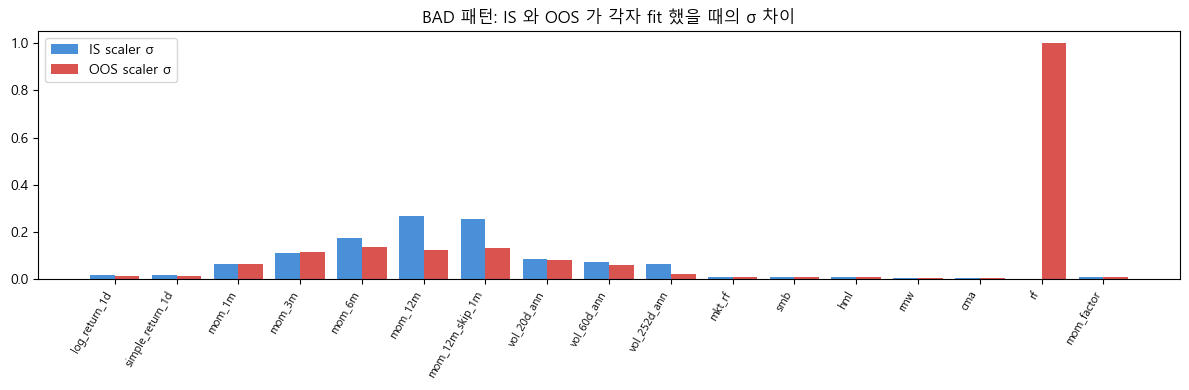

In [10]:
# ── 시각화: 두 scaler 의 σ 를 피처별로 비교
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(FEATURE_COLS))
w = 0.4
ax.bar(x - w/2, bad_is._scaler.scale_,  w, label='IS scaler σ',  color='#4a90d9')
ax.bar(x + w/2, bad_oos._scaler.scale_, w, label='OOS scaler σ', color='#d9534f')
ax.set_xticks(x); ax.set_xticklabels(FEATURE_COLS, rotation=60, ha='right', fontsize=8)
ax.set_title('BAD 패턴: IS 와 OOS 가 각자 fit 했을 때의 σ 차이')
ax.legend()
plt.tight_layout(); plt.show()

## Step 8. 자가 점검 질문 해설 + 체크리스트

### 질문과 답

**Q1. Dataset 과 DataLoader 의 책임을 한 문장씩으로?**
- **Dataset**: "idx 를 주면 샘플 하나를 돌려주는 인덱스 룩업 규약" — 무거운 전처리(windowing, scaling) 는 `__init__` 에서 끝낸다.
- **DataLoader**: "Dataset 위에 배치·셔플·병렬로드를 얹는 래퍼" — 몇 개씩 묶을지, 섞을지, 몇 개 프로세스로 미리 뽑을지만 결정.

**Q2. 시계열에서 `shuffle=True` 는 되는데 `KFold(shuffle=True)` 는 안 되는 이유?**
- DataLoader 의 `shuffle` 은 **이미 split 된 IS 안에서** 배치 순서를 섞는 것 — 경계를 넘지 않음.
- KFold 의 `shuffle` 은 **split 단계 자체** 에서 시간 순서를 깨는 것 — 2.3 [B] 에서 확인했듯이 미래 엿보기.
- 즉 "어느 단계의 셔플인가" 가 다르다.

**Q3. `num_workers > 0` 으로 늘렸는데 오히려 느려진 3가지 원인?**
1. `__getitem__` 이 가볍다면 프로세스 간 통신(IPC) 오버헤드가 계산보다 커짐
2. Windows 는 `fork` 대신 `spawn` 을 쓰므로 워커 생성 비용이 큼 (`if __name__ == '__main__':` 필요)
3. 데이터셋이 메모리에 작게 들어가면 어차피 병렬화 이득 없음

**Q4. fold 마다 scaler 를 새로 fit 해야 하는 이유?**
- 2.3 에서 확인: 전체 기간 fit = 정규화 누수 (BAD scaler μ 최대 차이 0.0266).
- walk-forward 의 각 fold 는 **다른 IS 구간** 을 가짐 → IS 가 바뀌면 기준 통계도 바뀌어야 함.
- Dataset 은 그저 scaler 를 받기만 하므로, **바깥 루프에서 fold 마다 fit → 주입** 하면 자동으로 해결.

### 설계 체크리스트

- [x] `__init__` 에서 sliding window 와 scaler.transform 을 모두 처리했는가?
- [x] scaler 는 **Dataset 외부에서 fit** 된 객체를 주입받는가?
- [x] `__len__` 이 NaN 제거 후 유효 샘플 수 와 일치하는가?
- [x] `__getitem__` 이 `(X, y)` 를 tensor 로 반환하는가?
- [x] 학습=shuffle True / 평가=shuffle False 로 분기했는가?
- [ ] walk-forward 각 fold 마다 Dataset 과 scaler 를 새로 만들 준비가 됐는가? (← 4주차에 통합)

### 이 노트북이 준 핵심 교훈 3줄

1. `__init__` 에서 무거운 일 다 끝내면 `__getitem__` 은 O(1) → DataLoader 병렬 이득 극대화
2. scaler 는 **밖에서 fit, 안에서 transform** — 이 한 줄이 leakage 방지의 핵심
3. Dataset 내부 `fit_transform` 은 "코드는 짧지만 실험 결과를 신뢰할 수 없게 만드는 함정"

### 다음 단계 → 2.5 텐서 차원의 의미 (Batch, Time, Feature)
우리가 지금까지 만든 배치 shape `(B, T, F) = (64, 60, 17)` — 이 세 축이 PyTorch GRU 에 어떻게 전달되는지, `batch_first=True/False` 에 따라 어떻게 달라지는지를 다음 토픽에서 정리합니다. 3주차 GRU 구현 직전 단계입니다.